In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import load_data

In [3]:
df = load_data()

df.head()

,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,Weather_Condition,Promotion,Competitor_Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df[[
    "Product_ID",
    "Inventory_Level",
    "Demand",
    "Units_Sold"
]].head()

,Product_ID,Inventory_Level,Demand,Units_Sold
0,P0001,195,115,102
1,P0002,117,229,117
2,P0003,247,157,114
3,P0004,139,52,45
4,P0005,152,59,65


In [5]:
avg_demand = (
    df.groupby("Product_ID")["Demand"]
      .mean()
      .reset_index()
)

avg_demand.rename(
    columns={"Demand": "Average_Daily_Demand"},
    inplace=True
)

avg_demand.head()

,Product_ID,Average_Daily_Demand
0,P0001,109.591316
1,P0002,112.066579
2,P0003,103.995263
3,P0004,115.396053
4,P0005,107.520526


In [6]:
inventory = (
    df.groupby("Product_ID")["Inventory_Level"]
      .last()
      .reset_index()
)

inventory.head()

,Product_ID,Inventory_Level
0,P0001,267
1,P0002,156
2,P0003,212
3,P0004,141
4,P0005,288


In [7]:
inventory_df = avg_demand.merge(
    inventory,
    on="Product_ID"
)

inventory_df.head()

,Product_ID,Average_Daily_Demand,Inventory_Level
0,P0001,109.591316,267
1,P0002,112.066579,156
2,P0003,103.995263,212
3,P0004,115.396053,141
4,P0005,107.520526,288


In [8]:
LEAD_TIME = 7
SAFETY_FACTOR = 1.5

inventory_df["Safety_Stock"] = (
    inventory_df["Average_Daily_Demand"] * SAFETY_FACTOR
)

In [9]:
inventory_df["Reorder_Point"] = (
    inventory_df["Average_Daily_Demand"] * LEAD_TIME
    + inventory_df["Safety_Stock"]
)

In [10]:
inventory_df["Inventory_Status"] = np.where(
    inventory_df["Inventory_Level"] <= inventory_df["Reorder_Point"],
    "Reorder Required",
    "Sufficient Stock"
)

In [11]:
inventory_df["Recommended_Order"] = np.where(
    inventory_df["Inventory_Level"] < inventory_df["Reorder_Point"],
    inventory_df["Reorder_Point"] - inventory_df["Inventory_Level"],
    0
)

inventory_df.head()

,Product_ID,Average_Daily_Demand,Inventory_Level,Safety_Stock,Reorder_Point,Inventory_Status,Recommended_Order
0,P0001,109.591316,267,164.386974,931.526184,Reorder Required,664.526184
1,P0002,112.066579,156,168.099868,952.565921,Reorder Required,796.565921
2,P0003,103.995263,212,155.992895,883.959737,Reorder Required,671.959737
3,P0004,115.396053,141,173.094079,980.866447,Reorder Required,839.866447
4,P0005,107.520526,288,161.280789,913.924474,Reorder Required,625.924474


In [12]:
low_stock = inventory_df[
    inventory_df["Inventory_Status"] == "Reorder Required"
]

low_stock.head(10)

,Product_ID,Average_Daily_Demand,Inventory_Level,Safety_Stock,Reorder_Point,Inventory_Status,Recommended_Order
0,P0001,109.591316,267,164.386974,931.526184,Reorder Required,664.526184
1,P0002,112.066579,156,168.099868,952.565921,Reorder Required,796.565921
2,P0003,103.995263,212,155.992895,883.959737,Reorder Required,671.959737
3,P0004,115.396053,141,173.094079,980.866447,Reorder Required,839.866447
4,P0005,107.520526,288,161.280789,913.924474,Reorder Required,625.924474
5,P0006,107.722368,266,161.583553,915.640132,Reorder Required,649.640132
6,P0007,115.023421,261,172.535132,977.699079,Reorder Required,716.699079
7,P0008,104.352105,154,156.528158,886.992895,Reorder Required,732.992895
8,P0009,118.506316,136,177.759474,1007.303684,Reorder Required,871.303684
9,P0010,111.069474,115,166.604211,944.090526,Reorder Required,829.090526


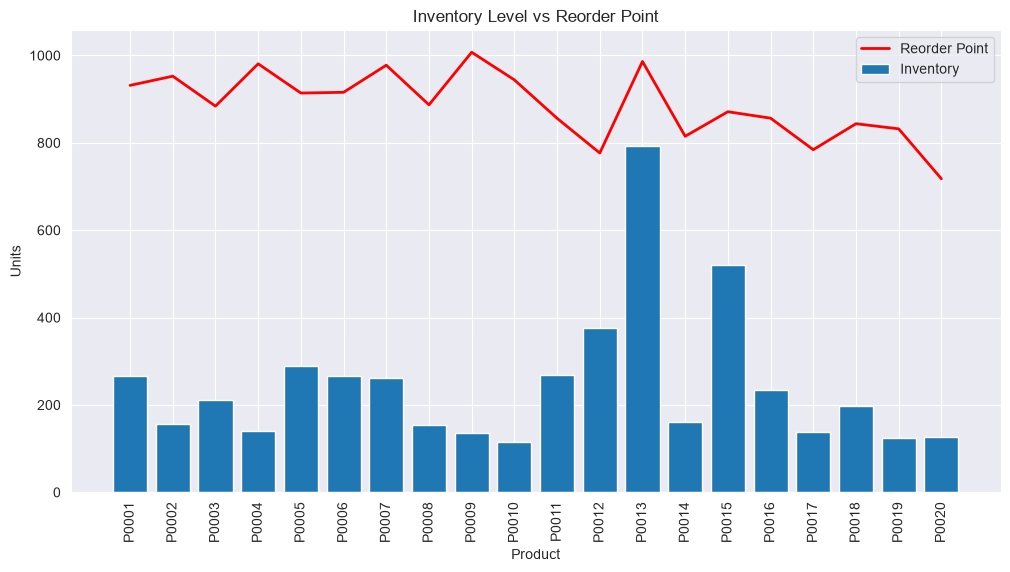

In [13]:
plt.figure(figsize=(12,6))

plt.bar(
    inventory_df["Product_ID"][:20],
    inventory_df["Inventory_Level"][:20],
    label="Inventory"
)

plt.plot(
    inventory_df["Product_ID"][:20],
    inventory_df["Reorder_Point"][:20],
    color="red",
    linewidth=2,
    label="Reorder Point"
)

plt.xticks(rotation=90)

plt.title("Inventory Level vs Reorder Point")
plt.xlabel("Product")
plt.ylabel("Units")

plt.legend()

plt.show()

In [16]:
# Save inventory optimization results

inventory_df.to_csv("../data/inventory_results.csv", index=False)

print("Inventory results saved successfully!")

Inventory results saved successfully!
